In [2]:
import sys
import os
import shap
import matplotlib.pyplot as plt
import joblib
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
from src.preprocessing import balance_training_data
from src.models import stacking_model
from src.evaluation import full_report

# ==============================
# 1️⃣ Load Features & Labels
# ==============================
X_train = pd.read_csv("../data/X_train_features.csv")
X_test = pd.read_csv("../data/X_test_features.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

# ==============================
# 2️⃣ Balance Training Data
# ==============================
X_train_bal, y_train_bal = balance_training_data(X_train, y_train)
print("Original Training Label Counts:")
print(y_train_bal.value_counts())

print("\nOriginal Test Label Counts:")
print(y_test.value_counts())
# ==============================
# 3️⃣ Train Stacking Model
# ==============================
stack = stacking_model()
stack.fit(X_train_bal, y_train_bal)

# ==============================
# 4️⃣ Evaluation
# ==============================
print("Stacking Model Evaluation:")
full_report(stack, X_test, y_test)



# ==============================
# 5️⃣ Save Trained Model
# ==============================

os.makedirs("../saved_models", exist_ok=True)

model_path = "../saved_models/stacking_phishing_model.pkl"

joblib.dump(stack, model_path)

print(f"\nModel saved successfully at: {model_path}")

Original Training Label Counts:
label
1    127356
0    127356
Name: count, dtype: int64

Original Test Label Counts:
label
0    69148
1    31839
Name: count, dtype: int64
Stacking Model Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     69148
           1       0.96      0.95      0.95     31839

    accuracy                           0.97    100987
   macro avg       0.97      0.96      0.97    100987
weighted avg       0.97      0.97      0.97    100987


Confusion Matrix:
[[67760  1388]
 [ 1648 30191]]

Model saved successfully at: ../saved_models/stacking_phishing_model.pkl



Generating SHAP explanations...


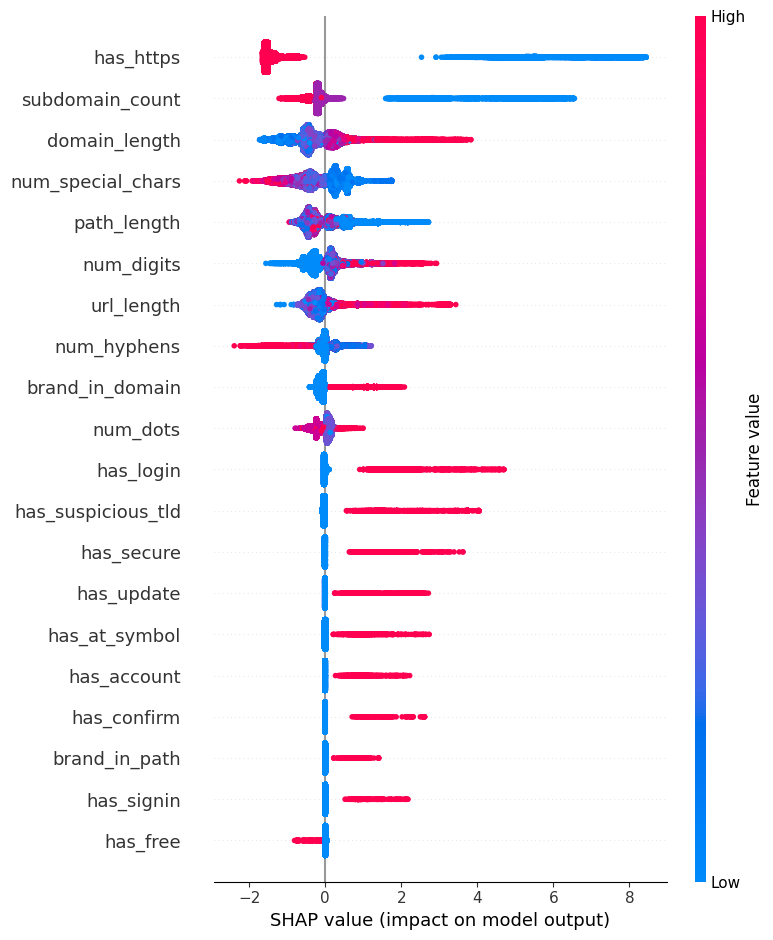

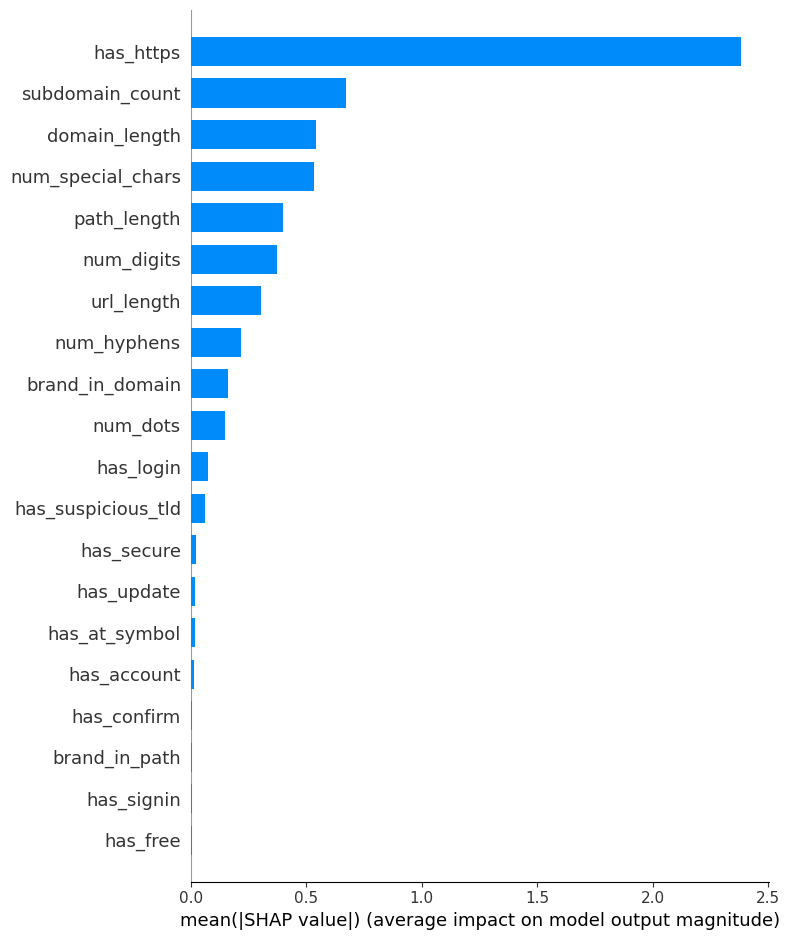

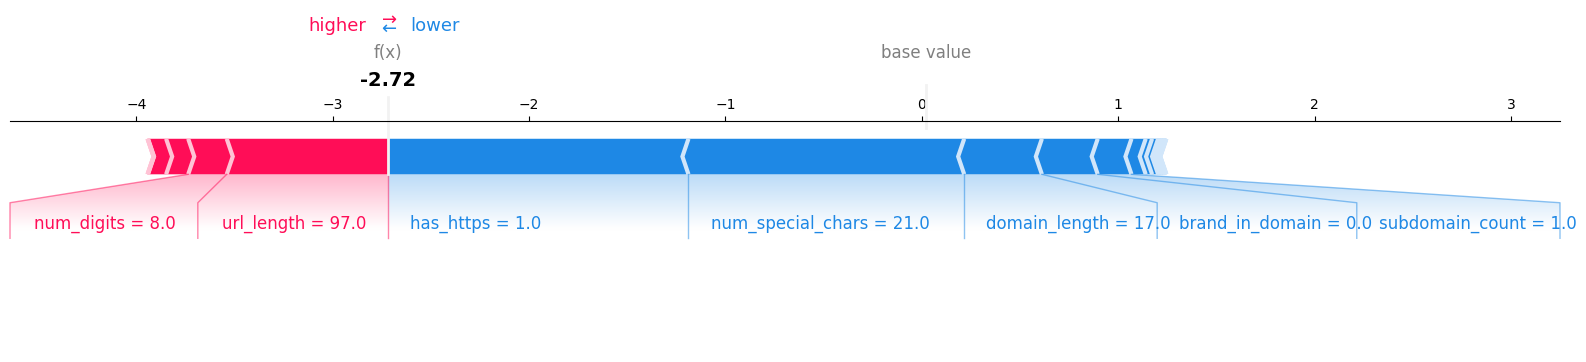

In [3]:

xgb_model = stack.named_estimators_["xgb"]
print("\nGenerating SHAP explanations...")

# Create explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar")

sample = X_test.iloc[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample,
    matplotlib=True
)


Enter a URL to test:  https://www.google.com



URL: https://www.google.com

Lexical Features:
url_length: 22
num_dots: 2
num_hyphens: 0
num_digits: 0
num_special_chars: 5

Structural Features:
has_https: 1
domain_length: 14
path_length: 0
has_ip: 0
subdomain_count: 1
has_at_symbol: 0
double_slash_redirect: 0
long_url: 0
has_suspicious_tld: 0
has_suspicious_ext: 0
brand_in_domain: 1
brand_in_path: 0

Semantic Features:
has_login: 0
has_verify: 0
has_secure: 0
has_account: 0
has_update: 0
has_bank: 0
has_confirm: 0
has_signin: 0
has_paypal: 0
has_ebay: 0
has_free: 0
has_bonus: 0

Advanced Security Features:
trusted_domain: 1
brand_mismatch: 0
has_shortener: 0
keyword_count: 0

Prediction Result:
✅ Legitimate URL
Phishing Probability: 0.0531

Generating SHAP explanation...


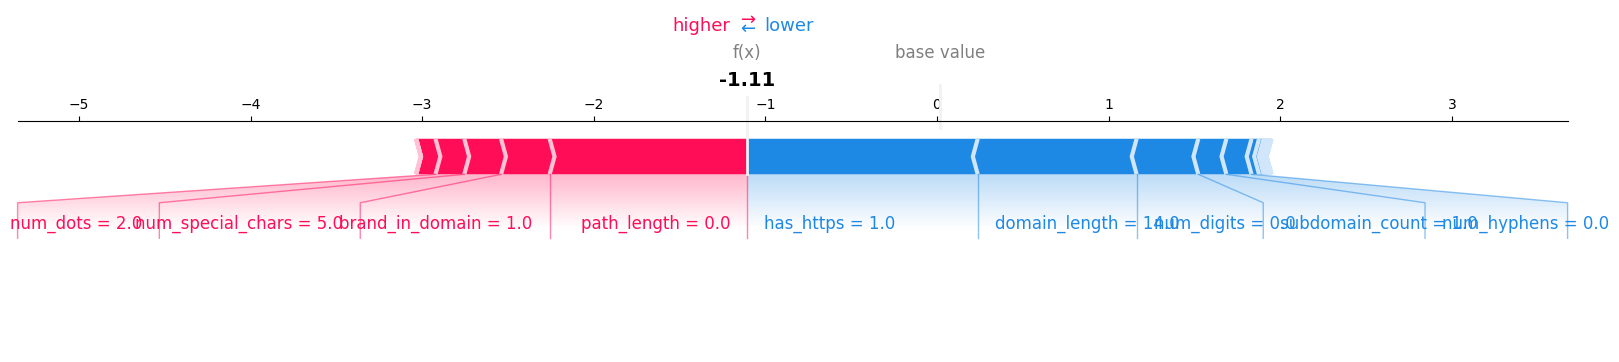

In [5]:
from src.feature_engineering import extract_single_url_features
# ==============================
# 5️⃣ Test with Sample URL
# ==============================

sample_url = input("\nEnter a URL to test: ")

features = extract_single_url_features(sample_url)

features_df = pd.DataFrame([features])
features_df = features_df.reindex(columns=X_train.columns, fill_value=0)

prediction = stack.predict(features_df)[0]
prob = stack.predict_proba(features_df)[0][1]

print("\nPrediction Result:")

if prediction == 1:
    print("⚠️ Phishing URL detected")
else:
    print("✅ Legitimate URL")

print(f"Phishing Probability: {prob:.4f}")

# ==============================
# SHAP Explanation
# ==============================

print("\nGenerating SHAP explanation...")

# Get XGBoost model from stacking
xgb_model = stack.named_estimators_["xgb"]

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the single URL
shap_values = explainer.shap_values(features_df)

# Force plot explanation
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    features_df.iloc[0],
    matplotlib=True
)